In [28]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch.optim as optim
import torch.nn as nn

In [29]:
from GraphSimulation import (
    TripartiteGraph,
    MatchingStrategy, 
    RandomStrategy, 
    GreedyStrategy, 
    RankStrategy, 

    SupervisedStrategy,
    TimeSeriesStrategy
)

from GraphSimulation import TripartiteGraphTrainer

In [30]:
n_Inodes = 100
n_Lnodes = 100
n_Rnodes = 100

OPTIMAL = min(n_Lnodes, n_Inodes, n_Rnodes)
RESULTS = {}

In [31]:
def generate_varNodes(inode_ids, n_Lnodes, n_Inodes, n_Rnodes, shuffle=False, seed= None,
                    lb:int=1, ub:int|None=None):
    rand_gen = np.random.default_rng(seed)
    nodes = []

    if(not ub): ub = n_Inodes + 1

    # Generate L nodes
    for _ in range(n_Lnodes):
        k = rand_gen.integers(lb, ub)
        candidates = rand_gen.choice(inode_ids, size=k, replace=False).tolist()
        nodes.append(("L", candidates))

    # Generate R nodes
    for _ in range(n_Rnodes):
        k = rand_gen.integers(lb, ub)
        candidates = rand_gen.choice(inode_ids, size=k, replace=False).tolist()
        nodes.append(("R", candidates))

    if shuffle: rand_gen.shuffle(nodes)
    return nodes

def simulate_online(graph: TripartiteGraph, node_order):
    for time, (node_type, candidates) in enumerate(node_order):
        if node_type == "L":
            graph.add_Lnode(time, candidates)
        else:
            graph.add_Rnode(time, candidates)
    return graph.matches

In [32]:
def run_experiment(arg:TripartiteGraph|MatchingStrategy|None=None, 
                runs=100, 
                n_inodes= n_Inodes, n_lnodes=n_Lnodes, n_rnodes=n_Rnodes, 
                seed:int|None= None, results= RESULTS):
    results_online = []
    rand_gen = np.random.default_rng(seed)

    # Handle the Graph
    if(not arg):
        print("No Graph or Strategy provided for experiment")
        return
    elif(isinstance(arg, TripartiteGraph)):
        g = arg
    elif(isinstance(arg, MatchingStrategy)):
        g = TripartiteGraph(arg, n_inodes)

    inode_ids = list(g.Inodes.keys())

    # Generate the nodes order
    node_order = generate_varNodes(inode_ids,
                        n_lnodes, n_inodes, n_rnodes, seed=seed)

    pbar = tqdm(range(runs), desc=f'Simulating: {g.strategy.name}')
    for _ in pbar:
        # Shuffle Nodes
        rand_gen.shuffle(node_order)

        # Online
        matches_online = simulate_online(g, node_order)
        results_online.append(matches_online)

        # Reset Graph
        g.reset()
    results[g.strategy.name] = results_online

## Supervised Training

In [33]:
# Teacher (strong heuristic)
teacher = RankStrategy(deterministic_partner= True)

# Student (AI)
student = SupervisedStrategy()

optimizer = optim.AdamW(student.parameters(), lr=1e-4, weight_decay= 1e-5)
criterion = nn.CrossEntropyLoss()

trainer = TripartiteGraphTrainer(
    teacher=teacher,
    student=student,
    n_inodes=n_Inodes,
    optimizer=optimizer,
    criterion=criterion,

    beta_threshold= 1.0
)

node_order = generate_varNodes(
    range(n_Inodes),
    n_Lnodes,
    n_Inodes,
    n_Rnodes,
)

trainer.train_supervised(node_order, epochs=500, verbose= False)

Model saved to ./models/SupervisedStrategy.pth
Training done


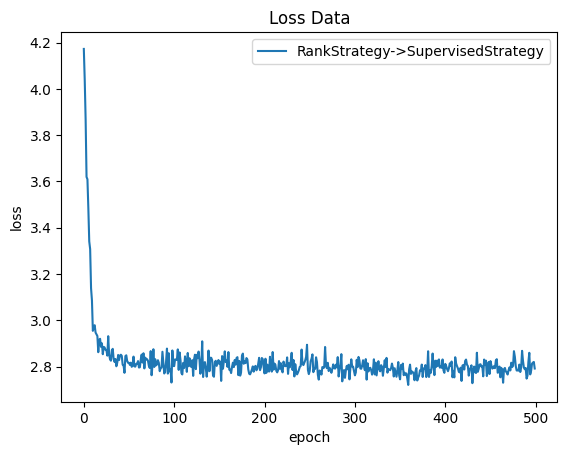

In [34]:
trainer.plot_graph()

In [35]:
RUN_SEED = 42

run_experiment(RandomStrategy(), seed= RUN_SEED)
run_experiment(GreedyStrategy(), seed= RUN_SEED)
run_experiment(RankStrategy(), seed= RUN_SEED)

model_strategy = SupervisedStrategy()
AIGraph = TripartiteGraph(model_strategy, n_Inodes=n_Inodes)
model_strategy.load()
#model_strategy.load(f"./models/{model_strategy.name}_best.pth")
model_strategy.eval()

run_experiment(AIGraph, seed= RUN_SEED)

Simulating: RankStrategy: 100%|██████████| 100/100 [00:00<00:00, 107.19it/s]


Model loaded from ./models/SupervisedStrategy.pth


Simulating: SupervisedStrategy: 100%|██████████| 100/100 [00:15<00:00,  6.60it/s]


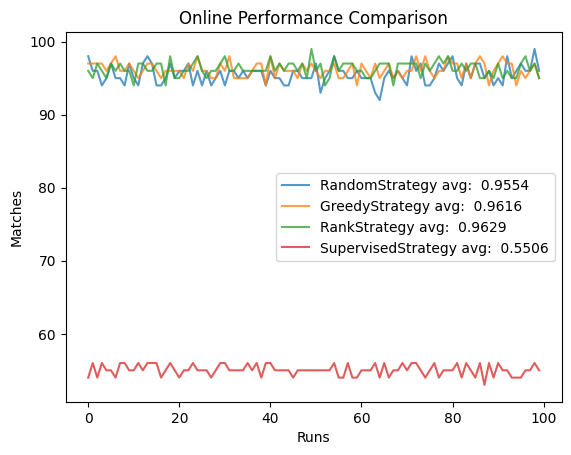

In [36]:
def plot_results(results= RESULTS, optimal= OPTIMAL):
    for res in results:
        plt.plot(results[res], alpha=0.75, label=f"{res} avg: {np.average(results[res]) / optimal: .4f}")

    plt.title("Online Performance Comparison")
    plt.xlabel("Runs")
    plt.ylabel("Matches")

    plt.legend()
    plt.show()

plot_results()